<a href="https://colab.research.google.com/github/sanmenghani/Random-Forest/blob/main/Random_Forest_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#Employee_Promotion_Prediction Random Forest project
from google.colab import files
upload = files.upload()

Saving Employee_Promotion_Prediction.csv to Employee_Promotion_Prediction.csv


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [5]:
df = pd.read_csv("Employee_Promotion_Prediction.csv")
print(df)

      Age  Experience_Years  Performance_Rating  Training_Hours  \
0      39                 7                   1              36   
1      51                20                   5              70   
2      48                15                   4              63   
3      43                11                   1              14   
4      33                 8                   5               6   
...   ...               ...                 ...             ...   
2495   27                 3                   1              20   
2496   36                 5                   5              63   
2497   50                17                   5              85   
2498   43                19                   3              58   
2499   44                19                   5              83   

      Projects_Completed  Attendance_Percentage Promotion  
0                     15                     84        No  
1                      9                     80       Yes  
2              

In [6]:
df.head()

,Age,Experience_Years,Performance_Rating,Training_Hours,Projects_Completed,Attendance_Percentage,Promotion
0,39,7,1,36,15,84,No
1,51,20,5,70,9,80,Yes
2,48,15,4,63,2,81,No
3,43,11,1,14,11,83,No
4,33,8,5,6,1,73,No


In [7]:
df['Promotion'].value_counts()

,count
Promotion,
No,1446
Yes,1054


In [8]:
df["Promotion"] = df["Promotion"].map({
    'No':0,
    'Yes':1
})

In [9]:
df.head()

,Age,Experience_Years,Performance_Rating,Training_Hours,Projects_Completed,Attendance_Percentage,Promotion
0,39,7,1,36,15,84,0
1,51,20,5,70,9,80,1
2,48,15,4,63,2,81,0
3,43,11,1,14,11,83,0
4,33,8,5,6,1,73,0


In [10]:
x = df[[
    'Age',
    'Experience_Years',
    'Performance_Rating',
    'Training_Hours',
    'Projects_Completed',
    'Attendance_Percentage'
]]
y=df['Promotion']

In [11]:
x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
model = RandomForestClassifier(
    n_estimators=77,
    random_state=42
)

In [13]:
model.fit(
    x_train,
    y_train
)
#random forest classifier is done with train date

RandomForestClassifier(n_estimators=77, random_state=42)

In [14]:
y_pred=model.predict(x_test)

In [15]:
accuracy=accuracy_score(y_test,y_pred)
print(
    "Accuracy:",
    round(accuracy*100,2),
    "%"
)

Accuracy: 96.2 %


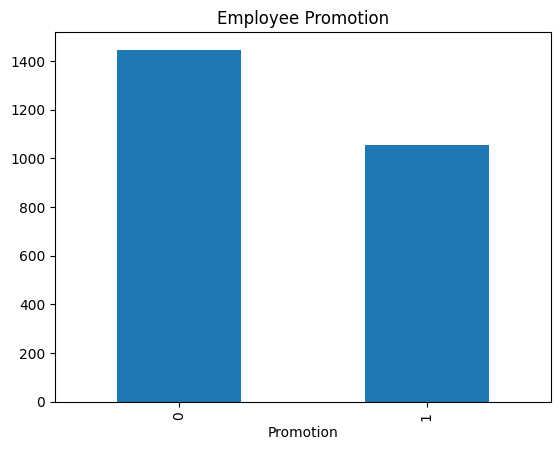

In [22]:
df["Promotion"].value_counts().plot(
    kind="bar"
)

plt.title("Employee Promotion")

plt.show()

In [24]:
cm = confusion_matrix(
    y_test,
    y_pred,)
print(cm)

[[259   9]
 [ 10 222]]


In [25]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.96      0.97      0.96       268
           1       0.96      0.96      0.96       232

    accuracy                           0.96       500
   macro avg       0.96      0.96      0.96       500
weighted avg       0.96      0.96      0.96       500



In [27]:
importance = pd.DataFrame({
    "Feature":x.columns,
    "Importance":model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)
#highest importance is number projects completed by .3


,Feature,Importance
4,Projects_Completed,0.425394
2,Performance_Rating,0.166322
1,Experience_Years,0.161114
3,Training_Hours,0.105783
0,Age,0.087182
5,Attendance_Percentage,0.054205


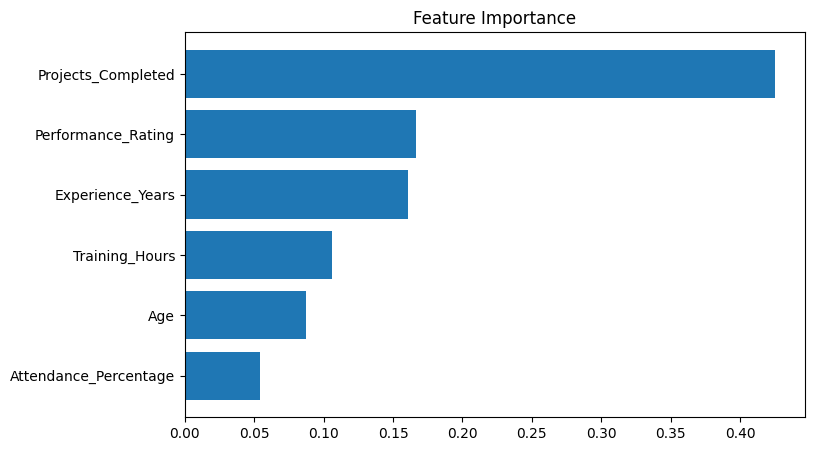

In [28]:
import matplotlib.pyplot as plt

importance = importance.sort_values(
    by="Importance"
)

plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title(
    "Feature Importance"
)

plt.show()

In [29]:
DecisionTreeClassifier()

DecisionTreeClassifier()

In [30]:
RandomForestClassifier()

RandomForestClassifier()